In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

import datasets_util
import vis_util
import lpca
from lego import lego, util
from sklearn.decomposition import PCA

VIS = vis_util.Visualize('figures/s1_puppets/')

matplotlib.get_backend() =  inline


In [3]:
# The image dataset used here is requested from
# Lederman, R. R., & Talmon, R. (2018). 
# Learning the geometry of common latent variables using alternating-diffusion.
# Applied and Computational Harmonic Analysis, 44(3), 509-536.

import paths_private_
X0_, labelsMat, imgs, img_shape = datasets_util.puppets_data(dirpath=paths_private_.data_path + '/PuppetsData/', prefix='s1', n_pca=0)

X.shape =  (8100, 57600)


In [4]:
img_shape

(120, 160, 3)

In [5]:
# add noise in images
noise_level = 1
np.random.seed(42)
noise = noise_level*np.random.uniform(-1,1, X0_.shape)
X_ = X0_ + noise

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.987860675773021..1.7910576750850407].


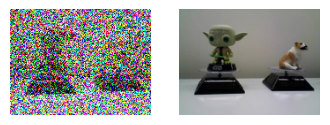

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9921168850430748..1.7758690261631054].


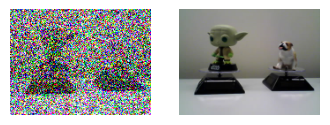

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9937517111122687..1.8132498785686628].


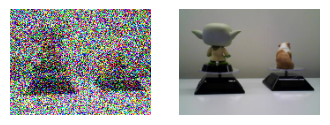

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.993755383640232..1.7741399817852375].


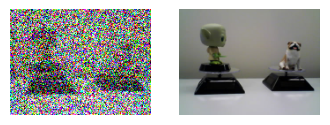

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9938486421026347..1.80569521322973].


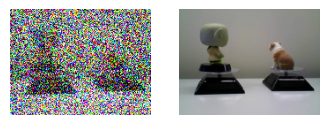

In [6]:
n_subsample_inds = 5
subsample_inds = np.random.choice(np.arange(X0_.shape[0]), n_subsample_inds, replace=False)
for i in subsample_inds.tolist():
    fig, axes = plt.subplots(1, 2, figsize=(4, 2))
    axes[0].imshow(X_[i,:].reshape(img_shape))
    axes[0].axis('off')
    axes[1].imshow(X0_[i,:].reshape(img_shape))
    axes[1].axis('off')
    plt.savefig(VIS.save_dir + '/sample_img_'+str(i)+'.png', dpi=600)
    plt.show()

In [7]:
# the ambient dimension is too high, we use global PCA to reduce it
pca_temp = PCA(n_components=30, random_state=42)
pca_temp.fit(X_)

,n_components,30
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


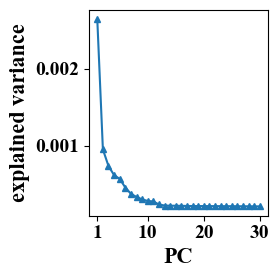

In [8]:
plt.figure(figsize=(3,3))
plt.plot(np.arange(30)+1, pca_temp.explained_variance_ratio_[:30], '-^', markersize=4)
plt.ylabel('explained variance')
plt.xlabel('PC')
plt.xticks([1,10,20,30])
plt.tight_layout()
plt.savefig(VIS.save_dir + '/global_variance_explained.png', dpi=600)
plt.show()

In [9]:
# reduce the ambient dimension based on where the explained variance saturates
pca = PCA(n_components=10, random_state=42)
X = pca.fit_transform(X_)

In [10]:
theta = X[:,2]

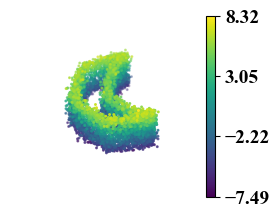

In [11]:
VIS.data(X[:,:3], theta, elev=45, azim=-15, cmap='viridis', colorbar=True, title='', save_fn='first_3_PCs', figsize=(3,3), show_axis=False)

In [12]:
emb_dim = 2
k_nn = 14

In [14]:
# free up memory
del X0_
del X_

# LPCA on noisy data

In [15]:
lpca_estimate = lpca.lpca(X, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})

# LEGO on noisy data

In [16]:
n_eig_for_grad = 20
n_eig = 100
lego_estimate = lego.lego(
    X,
    opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

# Local intrinsic dimension estimation

We simply change the embedding dimension to be equal to the ambient dimension plot the variance explained in each dimension

In [17]:
ambient_dim = X.shape[1]

In [18]:
lpca_estimate_for_lid = lpca.lpca(X, opts = {'emb_dim': ambient_dim, 'k_nn': k_nn})

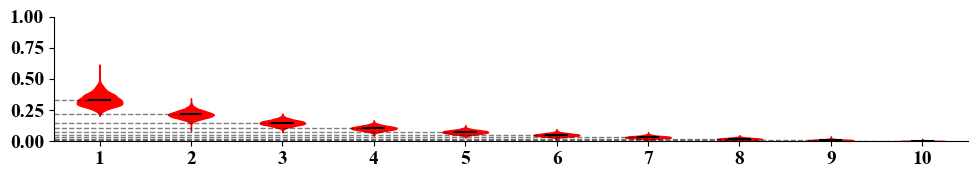

In [19]:
VIS.plot_var_exp_violin_plot(
    lpca_estimate_for_lid['var_explained'], color='r', save_fn='lpca_lid_estimate', figsize=(10, 2)
)

In [20]:
lego_estimate_for_lid = lego.lego(
    X,
    opts={'emb_dim': ambient_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

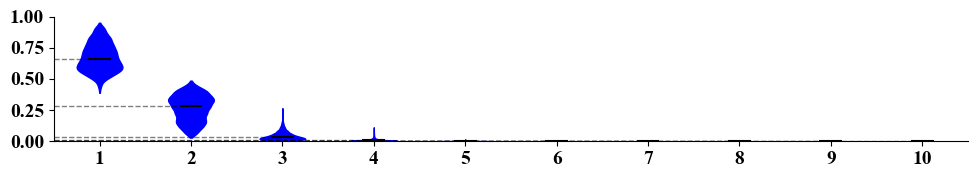

In [21]:
VIS.plot_var_exp_violin_plot(
    lego_estimate_for_lid['var_explained'], color='b', save_fn='lego_lid_estimate', figsize=(10, 2)
)

# Manifold Learning

The source is derived from feature/global-opts branch of https://github.com/Mishne-Lab/pyRATS commit: 8ad44b32a82cd6e52ad6ec17bd8b5917ec037582

Several options are turned off as these may improve the distortion of the low-dimensional local views obtained via projection on the estimated tangent spaces.

- `to_postprocess = False` prevents any postprocessing on local views computed from the tangent space estimates.
- `eta_min = 1` prevents formation of intermediate views (as they may improve upon local views).

Note that `eta_min = 1` significantly increases the time complexity of the algorithm, however, our main goal here is to evaluate the effect of tangent space estimates on the derived embedding without interference from the remaining components of the algorithm.

Also note that in this example we use `to_tear = True` to intentionally tear the closed manifold and embed it into its intrinsic dimension.

For more details please refer to https://www.biorxiv.org/content/10.1101/2024.10.31.621292v2

In [22]:
import sys
import paths_private_
sys.path.insert(0, paths_private_.codebase_path + '/pyRATS/src/')
from pyRATS import rats

def generate_embedding(point_cloud, model, tang_basis):
    model._fit_nbrhd_graph(point_cloud)
    model._fit_local_views(point_cloud)

    # override the local views using the estimated tangent basis
    model.param.Psi = tang_basis.transpose(0, 2, 1) # emb_dim is the last dimension
    
    c, n_C = model._fit_intermediate_views()
    y = model._fit_global_views(c, n_C)
    return y

In [23]:
model = rats.RATS(d=emb_dim, k=k_nn, alpha=1, max_iter=10, to_postprocess=False, eta_min=1, to_tear=True)
y_lpca = generate_embedding(X, model, lpca_estimate['tang_basis'])

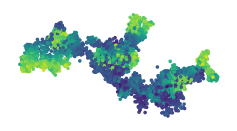

In [27]:
VIS.data(
    y_lpca, theta, cmap='viridis', figsize=(3,3), save_fn='y_lpca', show_axis=False, s=10
)

In [28]:
model = rats.RATS(d=emb_dim, k=k_nn, alpha=1, max_iter=10, to_postprocess=False, eta_min=1, to_tear=True)
y_lego = generate_embedding(X, model, lego_estimate['tang_basis'])

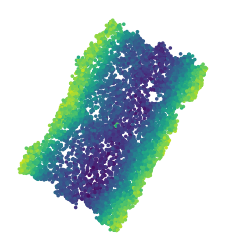

In [30]:
VIS.data(
    y_lego, theta, cmap='viridis', figsize=(3,3), save_fn='y_lpca', show_axis=False, s=10
)